In [1]:
import numpy as np


In [ ]:
n=8 #Número de partículas
# El problema intenta distribuir las partículas anteriores en una región cuadrada de 1x1 de manera que la distancia mínima entre ellas y con las paredes sea lo más grande posible.
def f(X): #Calcula la distancia menor entre las particulas unas con otras y con las paredes
  x=X[0::2]
  y=X[1::2]
  n=len(x)
  dmin=1000
  for i in range(n-1):
    for j in range(i+1,n):
      d=np.sqrt((x[i]-x[j])**2+(y[i]-y[j])**2)
      if d<dmin:
        dmin=d
  #Ahora de cada punto respecto a los bordes de la caja que los contiene
  for i in range(n):
    d1=x[i]*2 #Distancia a la pared izquierda
    d2=(1-x[i])*2 #Distancia a la pared derecha
    d3=(1-y[i])*2 #Distancia a la pared superior
    d4=y[i]*2 #Distancia a la pared inferior
    if d1<dmin:
      dmin=d1
    if d2<dmin:
      dmin=d2
    if d3<dmin:
      dmin=d3
    if d4<dmin:
      dmin=d4
  return dmin



In [10]:
class agente: #Esto representa una solución completa, es lo equivalente a una partícula en el PSO
  def __init__(self, funcion, W=1, C1=1, C2=1, n=8):
    self.X=np.random.uniform(low=0, high=1, size=2*n)
    self.V=0.2*np.random.randn(2*n)
    self.funcion=funcion
    self.PBest=self.X.copy()
    self.PBestValue=funcion(self.X)
    self.Gbest=self.X.copy()
    self.W=W
    self.C1=C1
    self.C2=C2
    self.historia=[self.X]
  def cambiar(self):
    self.V=self.W*self.V+self.C1*np.random.rand()*(self.PBest-self.X)+self.C2*np.random.rand()*(self.Gbest-self.X)
    self.X=self.X+self.V
    self.X[self.X>1]=1  
    self.X[self.X<0]=0
    self.historia.append(self.X)
    z=self.funcion(self.X)
    if(z>self.PBestValue):
      self.PBestValue=z
      self.PBest=self.X.copy()

def findGbest(agentes):
  vmax=0
  for ag in agentes:
    if(ag.PBestValue>vmax):
      vmax=ag.PBestValue
      Gbest=ag.PBest
  return Gbest


In [11]:
M=1000
from tqdm import tqdm
agentes=[agente(f, W=0.7, C1=0.1, C2=0.2, n=n) for i in range(M)]
error=[]
for i in tqdm(range(1000)):
  Gbest=findGbest(agentes)
  for ag in agentes:
    ag.Gbest=Gbest.copy()
  for ag in agentes:
    ag.cambiar()
  error.append(f(Gbest))


100%|██████████| 1000/1000 [05:02<00:00,  3.31it/s]


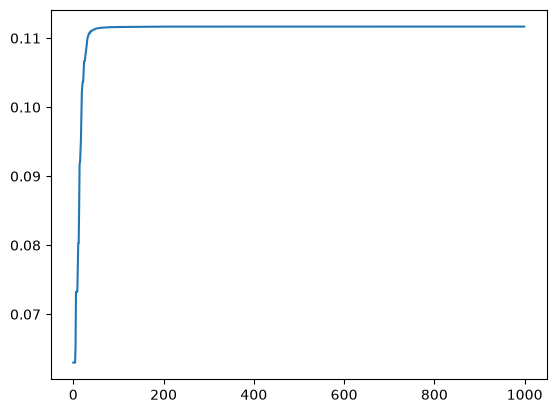

In [8]:
import matplotlib.pyplot as plt
plt.plot(error)

(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

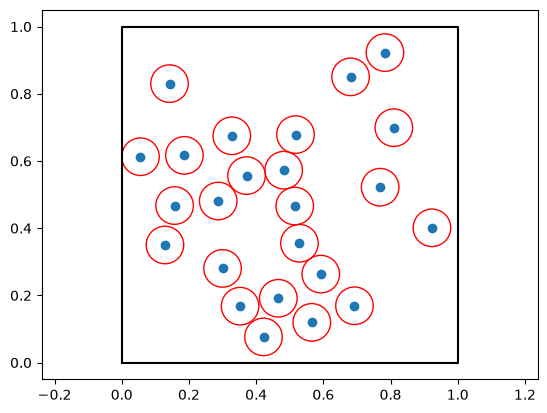

In [9]:
# Grafica de la mejor solución encontrada
xi=Gbest[0::2]
yi=Gbest[1::2]
plt.plot(xi, yi,'o')
dmax=f(Gbest)
for i in range(len(xi)):
  circle = plt.Circle((xi[i], yi[i]), dmax/2, color='r', fill=False)
  plt.gca().add_artist(circle)
plt.plot([0,1,1,0,0],[0,0,1,1,0],'k')
plt.axis('equal')